# Linear Regression 

This notebook implements **simple linear regression** using Python and NumPy.

The goal is to understand the core ideas behind linear regression before using machine learning libraries such as scikit-learn.

## 1. Problem Setup

We want to fit a straight line to data:

$$
f_{w,b}(x) = wx + b
$$

Where:

- $w$ is the slope/weight
- $b$ is the bias/intercept
- $x$ is the input feature
- $f_{w,b}(x)$ is the model prediction

## 2. Cost function

To measure how wrong the model is, we use the mean squared error cost:

$$
J(w,b) = \frac{1}{2m}\sum_{i=1}^{m}(f_{w,b}(x^{(i)}) - y^{(i)})^2
$$

Gradient descent will try to minimize this cost.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 3. Data Sets
I will be using this data set to train the model

In [2]:
x_train = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
y_train = np.array([52, 55, 61, 64, 68, 72, 74, 79, 83, 87])

## 4. Loop Implementation

This version calculates the cost and gradients using regular Python loops.  
It is useful for understanding what is happening step by step.

I renamed these functions with `_loop` so they do not get overwritten by the NumPy versions later.

In [3]:
def compute_cost_loop(x,y,w,b):
    x_size = len(x)
    cost = 0

    for i in range(x_size):
        f = w*x[i] +b
        cost = cost + (f-y[i])**2

    cost = cost/(2*x_size)
    return cost

def compute_gradient_loop(x,y,w,b):
    x_size = len(x)
    dw = 0
    db = 0

    for i in range(x_size):
        f = w*x[i] + b
        dw = dw + ((f-y[i]) * x[i])
        db = db + (f-y[i])
        
    dw = dw/x_size
    db = db/x_size
    return dw, db

## 5. NumPy Implementation

This version does the same thing as the loop version, but uses NumPy operations.

This is shorter and faster because NumPy can perform calculations on the whole array at once.

In [4]:
def compute_cost(x, y, w, b):
    x = np.array(x)
    y = np.array(y)

    m = len(x)
    f = w*x + b

    return np.sum(((f-y)**2)) / (2*m)


def compute_gradient(x, y, w, b):
    x = np.array(x)
    y = np.array(y)

    m = len(x)
    f = w*x + b

    dw = np.dot(f-y,x)/m
    db = np.sum(f-y)/m
    
    return dw, db


In [5]:
test_cost_loop = compute_cost_loop(x_train, y_train, 0, 0)
test_cost_numpy = compute_cost(x_train, y_train, 0, 0)

print(f"Loop cost: {test_cost_loop}")
print(f"NumPy cost: {test_cost_numpy}")

Loop cost: 2476.45
NumPy cost: 2476.45


## 6. Gradient Descent

Gradient descent updates $w$ and $b$ repeatedly to reduce the cost.

Update rules:

$$
w = w - \alpha \frac{\partial J}{\partial w}
$$

$$
b = b - \alpha \frac{\partial J}{\partial b}
$$

Here, $\alpha$ is the learning rate.

In [6]:
def gradient_descent(x,y,w,b,alpha,iterations):
    cost_history = []

    for i in range(iterations):
        dw, db = compute_gradient(x,y,w,b)
        w = w- alpha*dw
        b = b- alpha*db
        cost_history.append(compute_cost(x,y,w,b))
        
    return w,b, cost_history


## 7. Training the Model

Now we train the model on a small dataset and use gradient descent to find the best values of $w$ and $b$.

In [7]:
w,b = 0,0
alpha = 0.01
iterations = 50000

w, b, cost_history = gradient_descent(x_train,y_train,w,b,alpha, iterations)

print(f"w = {w:.4f}, b = {b:.4f}")
print(f"Final cost = {cost_history[-1]:.4f}")
print(f"Regression line: y = {w:.4f}x + {b:.4f}")

w = 3.8485, b = 48.3333
Final cost = 0.2303
Regression line: y = 3.8485x + 48.3333


## 8. Cost Over Time

The graph below shows how the cost decreases as gradient descent runs.

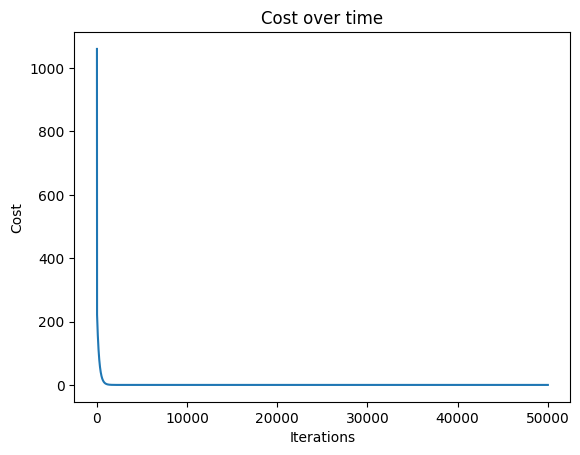

In [8]:
plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost over time")
plt.show()

## 9. Final Regression Line

The scatter plot shows the original data points.  
The line shows the model's learned prediction.

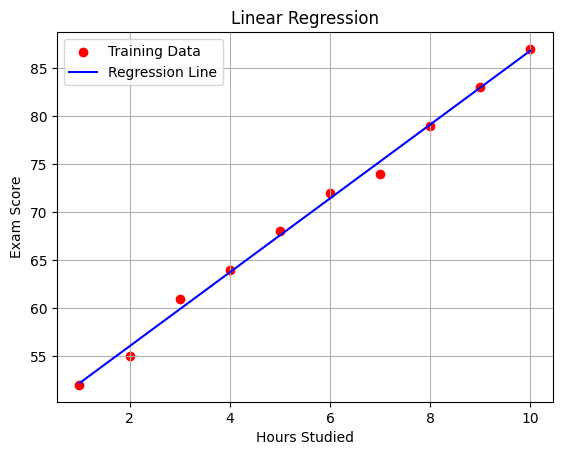

In [9]:
plt.scatter(x_train, y_train, color="red", label="Training Data")
plt.plot(x_train, w * x_train + b, color="blue", label="Regression Line")

plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Linear Regression")
plt.legend()
plt.grid(True)
plt.show()

## 10. Conclusion

In this notebook, I implemented simple linear regression from scratch using gradient descent. I started with a loop-based implementation to understand the calculations step by step, then used NumPy to write the same logic more efficiently.

The model learns by repeatedly calculating the cost, finding the gradients, and updating the parameters $w$ and $b$. As training continues, the cost decreases, showing that gradient descent is moving the model toward a better fit.

This project helped me understand the internal working of linear regression instead of only relying on built-in machine learning libraries.
